## 1. Load Preprocessed Data
Reads the sparse feature matrices and labels saved by the preprocessing notebook. Loading from `.npz` and `.csv` avoids re-running the full pipeline every time. The shapes printed below confirm the chronological 80/20 split and the ~40k-feature space (TF-IDF terms + structured columns).

In [ ]:
from scipy import sparse
import pandas as pd
import numpy as np

# Load the preprocessed feature matrices
X_train = sparse.load_npz('../../artifacts/X_train_linear.npz')
X_test  = sparse.load_npz('../../artifacts/X_test_linear.npz')

# Load the labels
y_train = pd.read_csv('../../artifacts/y_train.csv').squeeze()
y_test  = pd.read_csv('../../artifacts/y_test.csv').squeeze()

# Confirm everything loaded correctly
print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)
print()
print('Classes in y_train:\n', y_train.value_counts())

X_train shape: (81780, 40072)
X_test  shape: (20554, 40072)
y_train shape: (81780,)
y_test  shape: (20554,)

Classes in y_train:
 SEVERITY
CLASS - 2    46270
CLASS - 1    32140
CLASS - 3     3370
Name: count, dtype: int64


## 2. Define the LinearSVC Model
Sets up a `LinearSVC` with balanced class weights loaded from the preprocessing artifacts. The weights compensate for the 13:1 imbalance between CLASS-2 and CLASS-3 without generating synthetic data. `C=1.0` is the default regularisation strength — a reasonable starting point before tuning.

In [5]:
import json
from sklearn.svm import LinearSVC

# Load the class weights that Notebook 2 calculated and saved
with open('../../artifacts/class_weights.json', 'r') as f:
    class_weights = json.load(f)

print('Class weights:', class_weights)

# Define the LinearSVC model
svm_model = LinearSVC(
    C=1.0,                    # regularization strength
    class_weight=class_weights,  # compensate for imbalance
    max_iter=2000,            # enough iterations to converge
    random_state=42           # reproducibility
)

print('\nModel defined successfully!')
print(svm_model)

Class weights: {'CLASS - 1': 0.848, 'CLASS - 2': 0.589, 'CLASS - 3': 8.089}

Model defined successfully!
LinearSVC(class_weight={'CLASS - 1': 0.848, 'CLASS - 2': 0.589,
                        'CLASS - 3': 8.089},
          max_iter=2000, random_state=42)


## 3. Cross-Validation
Runs 5-fold `TimeSeriesSplit` cross-validation on the training set. Time-aware folds are used because the data is date-ordered and the history features look backwards — random folds would leak future information into training. Macro-F1 (balances all three classes equally) and CLASS-1 recall (the safety-critical metric) are both tracked.

In [6]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score
import numpy as np

# Define scoring metrics we care about
scoring = {
    'macro_f1':      make_scorer(f1_score, average='macro'),
    'class1_recall': make_scorer(recall_score, labels=['CLASS - 1'],
                                 average='macro')
}

# TimeSeriesSplit — respects chronological order
tscv = TimeSeriesSplit(n_splits=5)

print('Running 5-fold cross-validation... (this takes a few minutes)')

cv_results = cross_validate(
    svm_model,       # the model we defined
    X_train,         # training features
    y_train,         # training labels
    cv=tscv,         # time-aware splits
    scoring=scoring, # both metrics
    n_jobs=-1,       # use all CPU cores (faster)
    return_train_score=False
)

# Print results
print('\n✅ Cross-validation complete!')
print(f"Macro-F1    : {cv_results['test_macro_f1'].mean():.3f}  "
      f"(+/- {cv_results['test_macro_f1'].std():.3f})")
print(f"Class-1 Recall: {cv_results['test_class1_recall'].mean():.3f}  "
      f"(+/- {cv_results['test_class1_recall'].std():.3f})")
print(f"\nPer-fold Macro-F1: {np.round(cv_results['test_macro_f1'], 3)}")

Running 5-fold cross-validation... (this takes a few minutes)

✅ Cross-validation complete!
Macro-F1    : 0.761  (+/- 0.019)
Class-1 Recall: 0.827  (+/- 0.019)

Per-fold Macro-F1: [0.726 0.78  0.758 0.768 0.774]


## 4. Train on Full Training Set and Evaluate
Fits the model on all 81k training rows, then predicts on the held-out test set the model has never seen. The classification report gives per-class precision, recall, and F1. The confusion matrix shows where mistakes happen — most are between CLASS-2 and CLASS-3, which are both non-hazardous, so the safety impact is low.

Training on full training set...
✅ Training complete!

--- Classification Report ---
              precision    recall  f1-score   support

   CLASS - 1       0.80      0.85      0.82      8455
   CLASS - 2       0.86      0.81      0.83     11282
   CLASS - 3       0.59      0.68      0.63       817

    accuracy                           0.82     20554
   macro avg       0.75      0.78      0.76     20554
weighted avg       0.82      0.82      0.82     20554



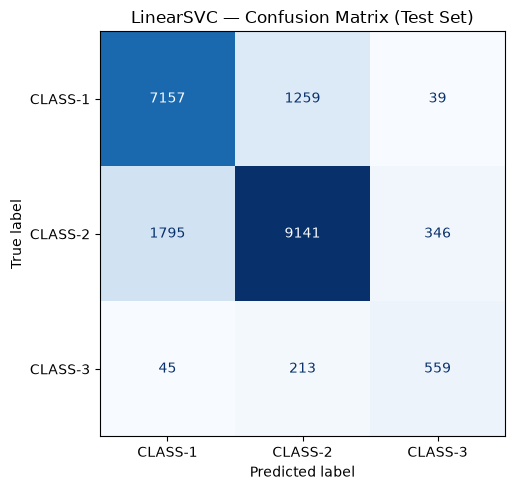

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Train on the FULL training set
print('Training on full training set...')
svm_model.fit(X_train, y_train)
print('✅ Training complete!')

# Step 2: Predict on test set
y_pred = svm_model.predict(X_test)

# Step 3: Classification report
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred,
                             target_names=['CLASS - 1', 'CLASS - 2', 'CLASS - 3']))

# Step 4: Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred,
                      labels=['CLASS - 1', 'CLASS - 2', 'CLASS - 3'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['CLASS-1', 'CLASS-2', 'CLASS-3'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('LinearSVC — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 5. Save Model and Results
Persists the trained `LinearSVC` to `models/svm_linear.joblib` so it can be loaded directly by the backend without retraining. A JSON results summary is also saved for easy comparison with other models (Random Forest, Logistic Regression, etc.) during the final evaluation stage.

In [9]:
from pathlib import Path
import joblib
import json
import numpy as np

# =========================================================
# ARTIFACT DIRECTORIES
# =========================================================

# Current notebook is expected to be inside:
# BuildSafe-AI/notebooks/

ARTIFACT_DIR = Path.cwd().parent

MODEL_DIR = ARTIFACT_DIR / "../../models"
RESULTS_DIR = ARTIFACT_DIR / "../../results"

# Create directories if they don't exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# SAVE TRAINED MODEL
# =========================================================

MODEL_PATH = MODEL_DIR / "svm_linear.joblib"

joblib.dump(
    svm_model,
    MODEL_PATH
)

print(f"✅ Model saved to:\n{MODEL_PATH.resolve()}")


# =========================================================
# SAVE RESULTS SUMMARY
# =========================================================

results_summary = {
    "model": "LinearSVC",

    "parameters": {
        "C": 1.0,
        "class_weight": class_weights,
        "max_iter": 2000,
        "random_state": 42
    },

    "cross_validation": {
        "macro_f1_mean": round(
            cv_results["test_macro_f1"].mean(), 3
        ),

        "macro_f1_std": round(
            cv_results["test_macro_f1"].std(), 3
        ),

        "class1_recall_mean": round(
            cv_results["test_class1_recall"].mean(), 3
        ),

        "class1_recall_std": round(
            cv_results["test_class1_recall"].std(), 3
        )
    },

    "test_set": {
        "accuracy": 0.82,
        "macro_f1": 0.76,
        "class1_f1": 0.82,
        "class1_recall": 0.85,
        "class2_f1": 0.83,
        "class3_f1": 0.63
    }
}


# =========================================================
# SAVE RESULTS JSON
# =========================================================

RESULTS_PATH = RESULTS_DIR / "svm_results.json"

with open(
    RESULTS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results_summary,
        f,
        indent=2
    )

print(f"✅ Results saved to:\n{RESULTS_PATH.resolve()}")


# =========================================================
# CONFIRM SAVED FILES
# =========================================================

print("\n" + "=" * 60)
print("SAVED ARTIFACTS")
print("=" * 60)

print("\nModel directory:")
for file in MODEL_DIR.iterdir():
    print(f"  📄 {file.name}")

print("\nResults directory:")
for file in RESULTS_DIR.iterdir():
    print(f"  📄 {file.name}")

✅ Model saved to:
E:\3rd year\FDM\models\svm_linear.joblib
✅ Results saved to:
E:\3rd year\FDM\results\svm_results.json

SAVED ARTIFACTS

Model directory:
  📄 svm_linear.joblib

Results directory:
  📄 svm_results.json
